# Rock Property Analysis for DEFAULT_ROCK_PROPERTIES

This notebook documents the derivation of `DEFAULT_ROCK_PROPERTIES` in `diffsim/data/seismic.py` from the `rock_physics_prod.db` database.

## Objective
Derive physically meaningful RHOB (density) and VP (P-wave velocity) mean and standard deviation for each of the 3 Flumy facies:
- **Bank (0)**: Overbank/floodplain (shale)
- **Channel (1)**: Heterogeneous channel fill (levee, crevasse splay)
- **Point Bar (2)**: Clean sand (laterally accreted reservoir target)

## Data Source
- Database: `rockdb/rock_physics_prod.db`
- Fields: Bongkot & Arthit (Gulf of Thailand)
- Tables: `well_logs`, `frm_brine_wells`, `frm_gas_wells`

## Facies Discrimination Logic
| DiffSim Facies | DB Source | Criteria |
|---|---|---|
| Bank (0) | `well_logs` shale | facies = 'shale' |
| Channel (1) | `frm_brine_wells` | brine sand, Vsh ≥ 0.15 |
| Point Bar (2) | `frm_gas_wells` | gas sand, Vsh < 0.15 |

**Rationale**: Point Bar in Flumy (PB+CL) are laterally accreted, clean, high-porosity sands — the primary gas reservoir target. Channel fill is more heterogeneous (higher Vsh). The Vsh=0.15 cutoff separates clean from dirty sand.

In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

DB_PATH = '../rockdb/rock_physics_prod.db'
FIELDS = ('Bongkot', 'Arthit')
VSH_CUTOFF = 0.15  # Vsh threshold to separate clean sand (Point Bar) from dirty sand (Channel)

## 1. Database Overview

In [2]:
conn = sqlite3.connect(DB_PATH)

# Get wells in target fields
wells_query = """
SELECT w.name, f.name as field_name
FROM wells w 
JOIN fields f ON w.field_id = f.id 
WHERE f.name IN ('Bongkot', 'Arthit')
"""
wells = conn.execute(wells_query).fetchall()
well_names = [w[0] for w in wells]
print(f"Total wells: {len(well_names)}")
print(f"\nBongkot: {[w[0] for w in wells if w[1]=='Bongkot']}")
print(f"\nArthit: {[w[0] for w in wells if w[1]=='Arthit']}")

Total wells: 26

Bongkot: ['BK-DEL-1', 'BK-DEL-18C', 'BK-DEL-40', 'TNY-5', 'PIKUL-2X', 'BK-20-K', 'TNY-1X', 'BK-29-G', 'BK-8-D', 'BK-DEL-22', 'BK-DEL-36', 'BK-DEL-37', 'TONCHAN-2X', 'TONSAK-7', 'TONSON-2', 'TR-2X']

Arthit: ['Arthit-15-1X', 'Arthit-16-8', 'Arthit-15-2X', 'Arthit-15-31', 'Arthit-14-20', 'Arthit-14-21-ST', 'Arthit-14-24', 'Arthit-15-27', 'Arthit-16-10', 'Arthit-16-11']


In [3]:
# Check available facies in well_logs
placeholders = ','.join(['?']*len(well_names))
query = f"""
SELECT facies, COUNT(*) as n
FROM well_logs 
WHERE well_name IN ({placeholders})
  AND rhob IS NOT NULL AND vp IS NOT NULL
GROUP BY facies
ORDER BY n DESC
"""
for row in conn.execute(query, well_names).fetchall():
    print(f"  {row[0]:12s}: {row[1]:>8,} samples")

  shale       :  214,321 samples
  brine       :   27,610 samples
  gas         :    8,626 samples
  coal        :    4,397 samples
  hc_others   :    1,200 samples


## 2. Raw Well Log Statistics by Facies

In [4]:
# Query all well_logs data
query = f"""
SELECT facies, rhob, vp, vsh
FROM well_logs 
WHERE well_name IN ({placeholders})
  AND rhob IS NOT NULL 
  AND vp IS NOT NULL
"""
results = conn.execute(query, well_names).fetchall()

data_by_facies = defaultdict(lambda: {'rhob': [], 'vp': [], 'vsh': []})
for facies, rhob, vp, vsh in results:
    data_by_facies[facies]['rhob'].append(rhob)
    data_by_facies[facies]['vp'].append(vp)
    if vsh is not None:
        data_by_facies[facies]['vsh'].append(vsh)

print(f"{'Facies':<12} {'N':>8} {'RHOB mean':>10} {'RHOB std':>10} {'VP mean':>10} {'VP std':>8} {'AI mean':>10} {'VSH mean':>10}")
print("-" * 90)
for facies in ['shale', 'brine', 'gas', 'coal', 'hc_others']:
    if facies not in data_by_facies:
        continue
    d = data_by_facies[facies]
    rhob = np.array(d['rhob'])
    vp = np.array(d['vp'])
    vsh = np.array(d['vsh']) if d['vsh'] else np.array([0])
    ai = rhob * vp
    print(f"{facies:<12} {len(rhob):>8,} {rhob.mean():>10.4f} {rhob.std():>10.4f} "
          f"{vp.mean():>10.1f} {vp.std():>8.1f} {ai.mean():>10.1f} {vsh.mean():>10.4f}")

Facies              N  RHOB mean   RHOB std    VP mean   VP std    AI mean   VSH mean
------------------------------------------------------------------------------------------
shale         214,321     2.5323     0.1495     3481.5    560.7     8862.1     0.7565
brine          27,610     2.2833     0.1084     3281.4    412.1     7527.3     0.1771
gas             8,626     2.3263     0.1128     3514.7    462.9     8217.3     0.1413
coal            4,397     2.0031     0.3465     2840.4    419.4     5775.0     0.4550
hc_others       1,200     2.3810     0.0750     3627.1    406.5     8652.4     0.1366


## 3. Vsh-Based Discrimination: Point Bar vs Channel

Sand facies (brine + gas) are split by Vsh threshold:
- **Vsh < 0.15**: Clean sand → Point Bar (laterally accreted, high porosity)
- **Vsh ≥ 0.15**: Dirty/heterogeneous sand → Channel (levee, crevasse splay, heterolithic fill)

In [5]:
# Split sands by Vsh
query = f"""
SELECT facies, rhob, vp, vsh
FROM well_logs 
WHERE well_name IN ({placeholders})
  AND rhob IS NOT NULL AND vp IS NOT NULL AND vsh IS NOT NULL
  AND facies IN ('brine', 'gas')
"""
results = conn.execute(query, well_names).fetchall()

clean_sand = {'rhob': [], 'vp': [], 'vsh': []}  # Point Bar
dirty_sand = {'rhob': [], 'vp': [], 'vsh': []}  # Channel

for facies, rhob, vp, vsh in results:
    if vsh < VSH_CUTOFF:
        clean_sand['rhob'].append(rhob)
        clean_sand['vp'].append(vp)
        clean_sand['vsh'].append(vsh)
    else:
        dirty_sand['rhob'].append(rhob)
        dirty_sand['vp'].append(vp)
        dirty_sand['vsh'].append(vsh)

print(f"Clean sand (Point Bar, Vsh<{VSH_CUTOFF}): N={len(clean_sand['rhob']):,}")
print(f"Dirty sand (Channel, Vsh>={VSH_CUTOFF}): N={len(dirty_sand['rhob']):,}")

Clean sand (Point Bar, Vsh<0.15): N=18,234
Dirty sand (Channel, Vsh>=0.15): N=18,002


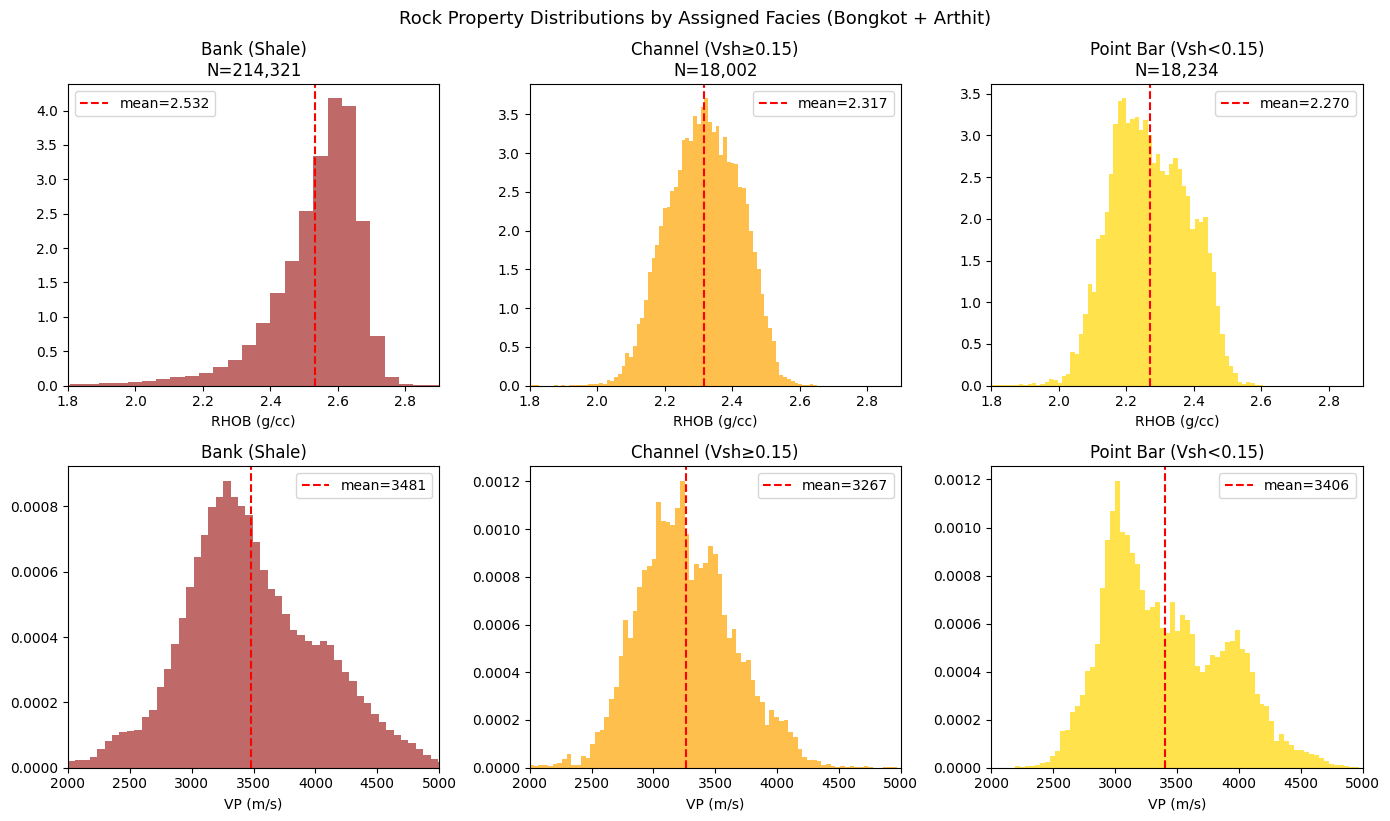

In [6]:
# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Get shale data
shale_rhob = np.array(data_by_facies['shale']['rhob'])
shale_vp = np.array(data_by_facies['shale']['vp'])
pb_rhob = np.array(clean_sand['rhob'])
pb_vp = np.array(clean_sand['vp'])
ch_rhob = np.array(dirty_sand['rhob'])
ch_vp = np.array(dirty_sand['vp'])

# RHOB histograms
for ax, (data, label, color) in zip(axes[0], 
    [(shale_rhob, 'Bank (Shale)', 'brown'),
     (ch_rhob, 'Channel (Vsh≥0.15)', 'orange'),
     (pb_rhob, 'Point Bar (Vsh<0.15)', 'gold')]):
    ax.hist(data, bins=80, density=True, alpha=0.7, color=color)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.3f}')
    ax.set_xlabel('RHOB (g/cc)')
    ax.set_title(f'{label}\nN={len(data):,}')
    ax.legend()
    ax.set_xlim(1.8, 2.9)

# VP histograms
for ax, (data, label, color) in zip(axes[1],
    [(shale_vp, 'Bank (Shale)', 'brown'),
     (ch_vp, 'Channel (Vsh≥0.15)', 'orange'),
     (pb_vp, 'Point Bar (Vsh<0.15)', 'gold')]):
    ax.hist(data, bins=80, density=True, alpha=0.7, color=color)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.0f}')
    ax.set_xlabel('VP (m/s)')
    ax.set_title(f'{label}')
    ax.legend()
    ax.set_xlim(2000, 5000)

plt.tight_layout()
plt.suptitle('Rock Property Distributions by Assigned Facies (Bongkot + Arthit)', y=1.02, fontsize=13)
plt.show()

## 4. FRM (Fluid Replacement Modeling) Data

For the seismic forward model, we use fluid-substituted data:
- **Channel**: FRM Brine (water-wet channel, non-reservoir)
- **Point Bar**: FRM Gas (gas-saturated reservoir target)
- **Bank**: Shale (no fluid substitution needed, dry rock)

This ensures consistent fluid fill and creates the physically correct AI hierarchy:
**Bank (shale) > Channel (brine sand) > Point Bar (gas sand)**

In [7]:
# Build Vsh lookup from well_logs
query = f"""
SELECT well_name, md, vsh
FROM well_logs 
WHERE well_name IN ({placeholders})
  AND vsh IS NOT NULL
  AND facies IN ('brine', 'gas')
"""
vsh_data = conn.execute(query, well_names).fetchall()
vsh_lookup = {(wn, round(md, 3)): vsh for wn, md, vsh in vsh_data}
print(f"Vsh lookup entries: {len(vsh_lookup):,}")

Vsh lookup entries: 36,236


In [8]:
# FRM Brine - for Channel (Vsh >= 0.15)
query = f"""
SELECT well_name, md, rhob, vp
FROM frm_brine_wells
WHERE well_name IN ({placeholders})
  AND rhob IS NOT NULL AND vp IS NOT NULL
  AND facies = 'brine'
"""
brine_results = conn.execute(query, well_names).fetchall()

frm_brine_channel = {'rhob': [], 'vp': []}
frm_brine_pb = {'rhob': [], 'vp': []}
for wn, md, rhob, vp in brine_results:
    key = (wn, round(md, 3))
    if key in vsh_lookup:
        if vsh_lookup[key] >= VSH_CUTOFF:
            frm_brine_channel['rhob'].append(rhob)
            frm_brine_channel['vp'].append(vp)
        else:
            frm_brine_pb['rhob'].append(rhob)
            frm_brine_pb['vp'].append(vp)

# FRM Gas - for Point Bar (Vsh < 0.15)
query = f"""
SELECT well_name, md, rhob, vp
FROM frm_gas_wells
WHERE well_name IN ({placeholders})
  AND rhob IS NOT NULL AND vp IS NOT NULL
  AND facies = 'gas'
"""
gas_results = conn.execute(query, well_names).fetchall()

frm_gas_pb = {'rhob': [], 'vp': []}
frm_gas_channel = {'rhob': [], 'vp': []}
for wn, md, rhob, vp in gas_results:
    key = (wn, round(md, 3))
    if key in vsh_lookup:
        if vsh_lookup[key] < VSH_CUTOFF:
            frm_gas_pb['rhob'].append(rhob)
            frm_gas_pb['vp'].append(vp)
        else:
            frm_gas_channel['rhob'].append(rhob)
            frm_gas_channel['vp'].append(vp)

print("FRM Brine - Channel (Vsh>=0.15):", len(frm_brine_channel['rhob']), "samples")
print("FRM Gas - Point Bar (Vsh<0.15):", len(frm_gas_pb['rhob']), "samples")

FRM Brine - Channel (Vsh>=0.15): 17097 samples
FRM Gas - Point Bar (Vsh<0.15): 17505 samples


In [9]:
# Summary of FRM data
print(f"{'Source':<35} {'RHOB mean':>10} {'RHOB std':>10} {'VP mean':>10} {'VP std':>8} {'AI mean':>10}")
print("-" * 90)

for name, d in [
    ("Bank (Shale, well_logs)", {'rhob': shale_rhob, 'vp': shale_vp}),
    ("Channel (FRM Brine, Vsh>=0.15)", {'rhob': np.array(frm_brine_channel['rhob']), 'vp': np.array(frm_brine_channel['vp'])}),
    ("Point Bar (FRM Gas, Vsh<0.15)", {'rhob': np.array(frm_gas_pb['rhob']), 'vp': np.array(frm_gas_pb['vp'])}),
]:
    rhob = d['rhob']
    vp = d['vp']
    ai = rhob * vp
    print(f"{name:<35} {rhob.mean():>10.4f} {rhob.std():>10.4f} {vp.mean():>10.1f} {vp.std():>8.1f} {ai.mean():>10.1f}")

Source                               RHOB mean   RHOB std    VP mean   VP std    AI mean
------------------------------------------------------------------------------------------
Bank (Shale, well_logs)                 2.5323     0.1495     3481.5    560.7     8862.1
Channel (FRM Brine, Vsh>=0.15)          2.3277     0.1075     3303.2    386.8     7724.2
Point Bar (FRM Gas, Vsh<0.15)           2.1462     0.1574     3259.6    556.9     7073.4


## 5. Per-Well Statistics (Manual Workflow Replication)

In manual practice, one plots the histogram for each facies for each well, reads the mean and standard deviation, then averages across wells. This approach:
1. Gives equal weight to each well (avoids bias from wells with more samples)
2. Captures the typical per-well variability
3. Is more robust to outlier wells

In [10]:
# Per-well statistics for each assigned facies
# Bank: shale from well_logs
# Channel: FRM brine sand with Vsh >= 0.15
# Point Bar: FRM gas sand with Vsh < 0.15

# Bank per-well
query = f"""
SELECT well_name, rhob, vp
FROM well_logs 
WHERE well_name IN ({placeholders})
  AND rhob IS NOT NULL AND vp IS NOT NULL
  AND facies = 'shale'
"""
bank_data = defaultdict(lambda: {'rhob': [], 'vp': []})
for wn, rhob, vp in conn.execute(query, well_names).fetchall():
    bank_data[wn]['rhob'].append(rhob)
    bank_data[wn]['vp'].append(vp)

# Channel per-well (FRM brine, Vsh >= 0.15)
channel_data = defaultdict(lambda: {'rhob': [], 'vp': []})
for wn, md, rhob, vp in brine_results:
    key = (wn, round(md, 3))
    if key in vsh_lookup and vsh_lookup[key] >= VSH_CUTOFF:
        channel_data[wn]['rhob'].append(rhob)
        channel_data[wn]['vp'].append(vp)

# Point Bar per-well (FRM gas, Vsh < 0.15)
pb_data = defaultdict(lambda: {'rhob': [], 'vp': []})
for wn, md, rhob, vp in gas_results:
    key = (wn, round(md, 3))
    if key in vsh_lookup and vsh_lookup[key] < VSH_CUTOFF:
        pb_data[wn]['rhob'].append(rhob)
        pb_data[wn]['vp'].append(vp)

MIN_SAMPLES = 20  # minimum samples per well to include

def compute_per_well_stats(well_dict, min_n=MIN_SAMPLES):
    """Compute mean-of-means and mean-of-stds across wells."""
    well_means_rhob, well_stds_rhob = [], []
    well_means_vp, well_stds_vp = [], []
    well_names_used = []
    for well, d in well_dict.items():
        if len(d['rhob']) >= min_n:
            rhob = np.array(d['rhob'])
            vp = np.array(d['vp'])
            well_means_rhob.append(rhob.mean())
            well_stds_rhob.append(rhob.std())
            well_means_vp.append(vp.mean())
            well_stds_vp.append(vp.std())
            well_names_used.append(well)
    return {
        'n_wells': len(well_names_used),
        'rhob_mean': np.mean(well_means_rhob),
        'rhob_std': np.mean(well_stds_rhob),
        'vp_mean': np.mean(well_means_vp),
        'vp_std': np.mean(well_stds_vp),
        'well_means_rhob': well_means_rhob,
        'well_means_vp': well_means_vp,
    }

stats_bank = compute_per_well_stats(bank_data)
stats_channel = compute_per_well_stats(channel_data)
stats_pb = compute_per_well_stats(pb_data)

print(f"{'Facies':<15} {'N wells':>8} {'RHOB mean':>10} {'RHOB std':>10} {'VP mean':>10} {'VP std':>8} {'AI':>8}")
print("-" * 75)
for name, s in [('Bank (0)', stats_bank), ('Channel (1)', stats_channel), ('Point Bar (2)', stats_pb)]:
    ai = s['rhob_mean'] * s['vp_mean']
    print(f"{name:<15} {s['n_wells']:>8} {s['rhob_mean']:>10.4f} {s['rhob_std']:>10.4f} "
          f"{s['vp_mean']:>10.1f} {s['vp_std']:>8.1f} {ai:>8.0f}")

Facies           N wells  RHOB mean   RHOB std    VP mean   VP std       AI
---------------------------------------------------------------------------
Bank (0)              26     2.5218     0.1271     3475.1    440.1     8764
Channel (1)           26     2.3482     0.0822     3417.0    295.6     8024
Point Bar (2)         26     2.1597     0.1190     3299.7    369.5     7126


/tmp/ipykernel_4008499/2536721430.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
/tmp/ipykernel_4008499/2536721430.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


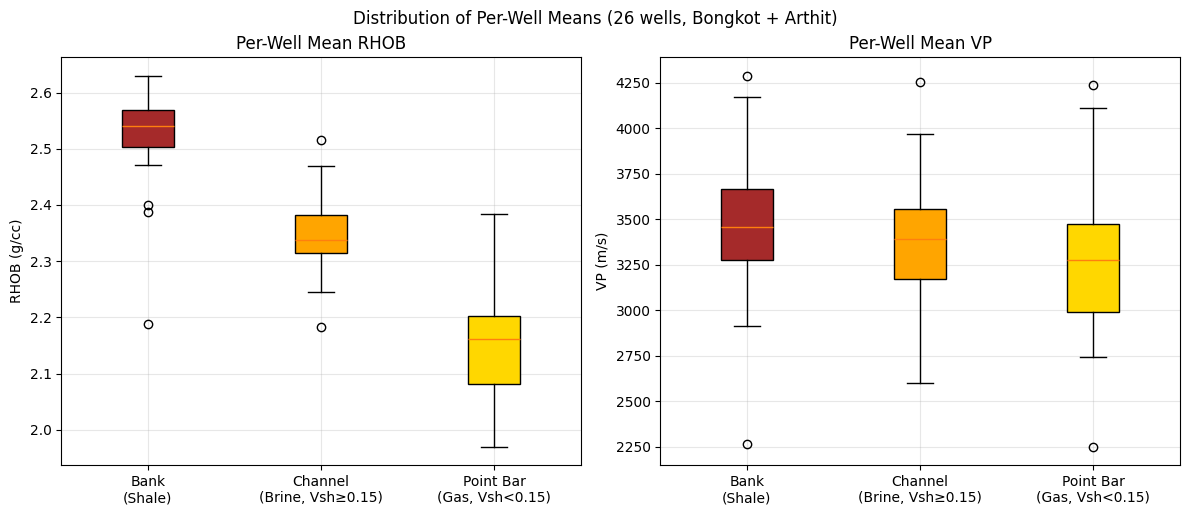

In [11]:
# Visualize per-well means as box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RHOB per-well means
bp1 = axes[0].boxplot(
    [stats_bank['well_means_rhob'], stats_channel['well_means_rhob'], stats_pb['well_means_rhob']],
    labels=['Bank\n(Shale)', 'Channel\n(Brine, Vsh≥0.15)', 'Point Bar\n(Gas, Vsh<0.15)'],
    patch_artist=True
)
colors = ['brown', 'orange', 'gold']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('RHOB (g/cc)')
axes[0].set_title('Per-Well Mean RHOB')
axes[0].grid(True, alpha=0.3)

# VP per-well means
bp2 = axes[1].boxplot(
    [stats_bank['well_means_vp'], stats_channel['well_means_vp'], stats_pb['well_means_vp']],
    labels=['Bank\n(Shale)', 'Channel\n(Brine, Vsh≥0.15)', 'Point Bar\n(Gas, Vsh<0.15)'],
    patch_artist=True
)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('VP (m/s)')
axes[1].set_title('Per-Well Mean VP')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Per-Well Means (26 wells, Bongkot + Arthit)', y=1.02)
plt.show()

## 6. AI Crossplot

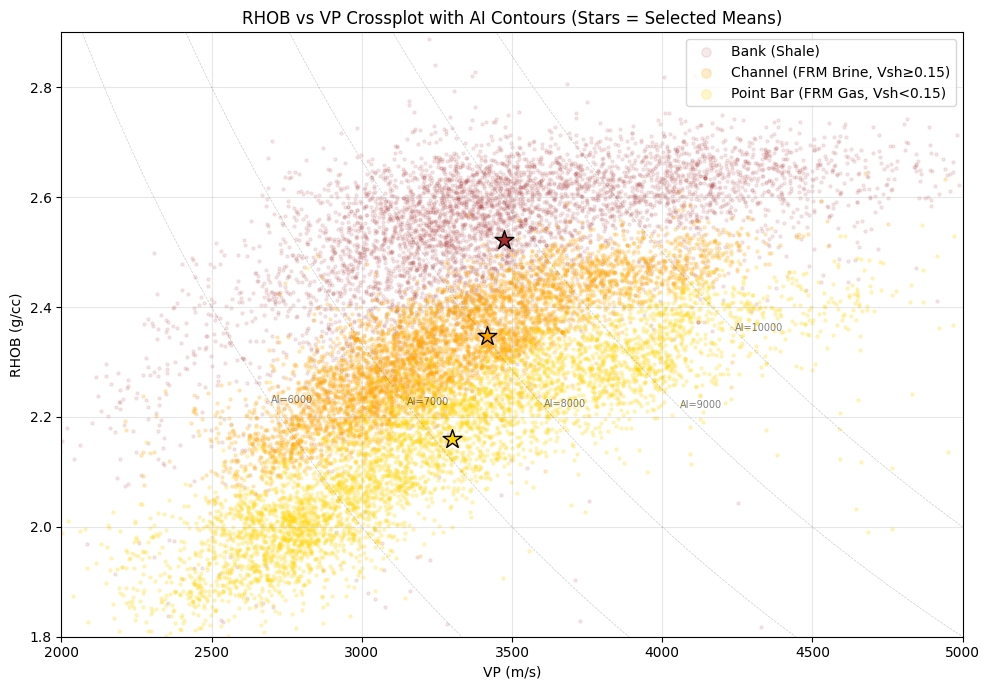

In [12]:
# AI crossplot: RHOB vs VP colored by facies
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Subsample for visibility
rng = np.random.default_rng(42)
n_plot = 5000

def subsample(arr, n):
    idx = rng.choice(len(arr), size=min(n, len(arr)), replace=False)
    return arr[idx]

# Bank
idx = rng.choice(len(shale_rhob), size=min(n_plot, len(shale_rhob)), replace=False)
ax.scatter(shale_vp[idx], shale_rhob[idx], alpha=0.1, s=5, c='brown', label='Bank (Shale)')

# Channel (FRM brine)
ch_r = np.array(frm_brine_channel['rhob'])
ch_v = np.array(frm_brine_channel['vp'])
idx = rng.choice(len(ch_r), size=min(n_plot, len(ch_r)), replace=False)
ax.scatter(ch_v[idx], ch_r[idx], alpha=0.2, s=5, c='orange', label='Channel (FRM Brine, Vsh≥0.15)')

# Point Bar (FRM gas)
pb_r = np.array(frm_gas_pb['rhob'])
pb_v = np.array(frm_gas_pb['vp'])
idx = rng.choice(len(pb_r), size=min(n_plot, len(pb_r)), replace=False)
ax.scatter(pb_v[idx], pb_r[idx], alpha=0.2, s=5, c='gold', label='Point Bar (FRM Gas, Vsh<0.15)')

# Plot selected means
ax.scatter([stats_bank['vp_mean']], [stats_bank['rhob_mean']], s=200, c='brown', marker='*', edgecolors='black', zorder=5)
ax.scatter([stats_channel['vp_mean']], [stats_channel['rhob_mean']], s=200, c='orange', marker='*', edgecolors='black', zorder=5)
ax.scatter([stats_pb['vp_mean']], [stats_pb['rhob_mean']], s=200, c='gold', marker='*', edgecolors='black', zorder=5)

# AI contours
vp_range = np.linspace(2000, 5000, 100)
for ai_val in [6000, 7000, 8000, 9000, 10000]:
    rhob_line = ai_val / vp_range
    ax.plot(vp_range, rhob_line, 'k--', alpha=0.2, linewidth=0.5)
    valid = (rhob_line > 1.8) & (rhob_line < 2.9)
    if valid.any():
        mid_idx = np.where(valid)[0][len(np.where(valid)[0])//2]
        ax.text(vp_range[mid_idx], rhob_line[mid_idx], f'AI={ai_val}', fontsize=7, alpha=0.5)

ax.set_xlabel('VP (m/s)')
ax.set_ylabel('RHOB (g/cc)')
ax.set_xlim(2000, 5000)
ax.set_ylim(1.8, 2.9)
ax.legend(markerscale=3)
ax.set_title('RHOB vs VP Crossplot with AI Contours (Stars = Selected Means)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Final Values: DEFAULT_ROCK_PROPERTIES

Based on per-well mean-of-means and mean-of-stds (rounded for practical use):

In [13]:
# Final values (as implemented in diffsim/data/seismic.py)
DEFAULT_ROCK_PROPERTIES = {
    0: {"rhob": (2.52, 0.13), "vp": (3475.0, 440.0)},  # Bank (shale overbank)
    1: {"rhob": (2.35, 0.08), "vp": (3415.0, 295.0)},  # Channel (brine sand, Vsh>=0.15)
    2: {"rhob": (2.16, 0.12), "vp": (3300.0, 370.0)},  # Point Bar (gas sand, Vsh<0.15)
}

print("DEFAULT_ROCK_PROPERTIES (diffsim/data/seismic.py)")
print("=" * 70)
print(f"{'Code':<6} {'Facies':<15} {'RHOB (g/cc)':<20} {'VP (m/s)':<20} {'AI':>8}")
print("-" * 70)
for code, props in DEFAULT_ROCK_PROPERTIES.items():
    rm, rs = props['rhob']
    vm, vs = props['vp']
    names = {0: 'Bank', 1: 'Channel', 2: 'Point Bar'}
    print(f"{code:<6} {names[code]:<15} {rm:.2f} ± {rs:.2f}       {vm:.0f} ± {vs:.0f}       {rm*vm:>8.0f}")

print(f"\nAI Contrasts:")
ai0 = DEFAULT_ROCK_PROPERTIES[0]['rhob'][0] * DEFAULT_ROCK_PROPERTIES[0]['vp'][0]
ai1 = DEFAULT_ROCK_PROPERTIES[1]['rhob'][0] * DEFAULT_ROCK_PROPERTIES[1]['vp'][0]
ai2 = DEFAULT_ROCK_PROPERTIES[2]['rhob'][0] * DEFAULT_ROCK_PROPERTIES[2]['vp'][0]
print(f"  Bank → Channel:    ΔAI = {ai0-ai1:.0f}")
print(f"  Channel → Pt Bar:  ΔAI = {ai1-ai2:.0f}")
print(f"  Bank → Pt Bar:     ΔAI = {ai0-ai2:.0f}")

DEFAULT_ROCK_PROPERTIES (diffsim/data/seismic.py)
Code   Facies          RHOB (g/cc)          VP (m/s)                   AI
----------------------------------------------------------------------
0      Bank            2.52 ± 0.13       3475 ± 440           8757
1      Channel         2.35 ± 0.08       3415 ± 295           8025
2      Point Bar       2.16 ± 0.12       3300 ± 370           7128

AI Contrasts:
  Bank → Channel:    ΔAI = 732
  Channel → Pt Bar:  ΔAI = 897
  Bank → Pt Bar:     ΔAI = 1629


In [14]:
# Per-field verification
print("\nPer-Field Breakdown:")
print("=" * 70)

for field in ['Bongkot', 'Arthit']:
    field_wells = [r[0] for r in conn.execute(
        "SELECT w.name FROM wells w JOIN fields f ON w.field_id = f.id WHERE f.name = ?",
        (field,)).fetchall()]
    ph = ','.join(['?']*len(field_wells))
    
    # Shale
    results = conn.execute(f"""
        SELECT rhob, vp FROM well_logs 
        WHERE well_name IN ({ph}) AND rhob IS NOT NULL AND vp IS NOT NULL AND facies = 'shale'
    """, field_wells).fetchall()
    rhob = np.array([r[0] for r in results])
    vp = np.array([r[1] for r in results])
    print(f"\n{field}:")
    print(f"  Bank (Shale):     RHOB={rhob.mean():.3f}±{rhob.std():.3f}, VP={vp.mean():.0f}±{vp.std():.0f}, AI={np.mean(rhob*vp):.0f}")
    
    # FRM Gas clean sand
    results = conn.execute(f"""
        SELECT well_name, md, rhob, vp FROM frm_gas_wells
        WHERE well_name IN ({ph}) AND rhob IS NOT NULL AND vp IS NOT NULL AND facies = 'gas'
    """, field_wells).fetchall()
    pb = [(r[2], r[3]) for r in results if (r[0], round(r[1], 3)) in vsh_lookup and vsh_lookup[(r[0], round(r[1], 3))] < VSH_CUTOFF]
    ch_gas = [(r[2], r[3]) for r in results if (r[0], round(r[1], 3)) in vsh_lookup and vsh_lookup[(r[0], round(r[1], 3))] >= VSH_CUTOFF]
    if pb:
        rhob = np.array([r[0] for r in pb])
        vp = np.array([r[1] for r in pb])
        print(f"  Point Bar (Gas):  RHOB={rhob.mean():.3f}±{rhob.std():.3f}, VP={vp.mean():.0f}±{vp.std():.0f}, AI={np.mean(rhob*vp):.0f}")
    
    # FRM Brine dirty sand
    results = conn.execute(f"""
        SELECT well_name, md, rhob, vp FROM frm_brine_wells
        WHERE well_name IN ({ph}) AND rhob IS NOT NULL AND vp IS NOT NULL AND facies = 'brine'
    """, field_wells).fetchall()
    ch = [(r[2], r[3]) for r in results if (r[0], round(r[1], 3)) in vsh_lookup and vsh_lookup[(r[0], round(r[1], 3))] >= VSH_CUTOFF]
    if ch:
        rhob = np.array([r[0] for r in ch])
        vp = np.array([r[1] for r in ch])
        print(f"  Channel (Brine):  RHOB={rhob.mean():.3f}±{rhob.std():.3f}, VP={vp.mean():.0f}±{vp.std():.0f}, AI={np.mean(rhob*vp):.0f}")

conn.close()


Per-Field Breakdown:

Bongkot:
  Bank (Shale):     RHOB=2.535±0.160, VP=3453±595, AI=8810
  Point Bar (Gas):  RHOB=2.151±0.161, VP=3247±581, AI=7067
  Channel (Brine):  RHOB=2.342±0.106, VP=3285±391, AI=7729

Arthit:
  Bank (Shale):     RHOB=2.529±0.132, VP=3524±501, AI=8941
  Point Bar (Gas):  RHOB=2.134±0.148, VP=3292±491, AI=7088
  Channel (Brine):  RHOB=2.303±0.106, VP=3334±378, AI=7717


## Summary

### Key Decisions

1. **Point Bar = Clean Sand (Vsh < 0.15)**: In Flumy, point bars (PB+CL) represent laterally accreted deposits — the cleanest, highest-porosity sand bodies. This maps to low-Vsh sand in well logs.

2. **Channel = Dirty Sand (Vsh ≥ 0.15)**: Channel fill (LV+CS2+CCH+CS1+SP) includes levee, crevasse splay, and heterolithic deposits — shalier and more variable.

3. **Fluid assignment**: Point Bar uses FRM Gas (reservoir target), Channel uses FRM Brine (water-wet), Bank uses in-situ shale. This creates the correct AI ordering for gas exploration.

4. **Per-well averaging**: Statistics computed as mean-of-per-well-means and mean-of-per-well-stds to avoid bias from wells with unequal sample counts.

### Result
```python
DEFAULT_ROCK_PROPERTIES = {
    0: {"rhob": (2.52, 0.13), "vp": (3475.0, 440.0)},  # Bank (shale)
    1: {"rhob": (2.35, 0.08), "vp": (3415.0, 295.0)},  # Channel (brine sand)
    2: {"rhob": (2.16, 0.12), "vp": (3300.0, 370.0)},  # Point Bar (gas sand)
}
```

AI hierarchy: Bank (8757) > Channel (8025) > Point Bar (7128)